In [25]:
import pandas as pd
import numpy as np

# load steering differential data
best_layers_X = pd.read_csv('../outputs/best_layers_X.csv')
best_layers_Y = pd.read_csv('../outputs/best_layers_Y.csv')

best_layers_X_llama = pd.read_csv('../outputs/best_layers_X_llama.csv')
best_layers_Y_llama = pd.read_csv('../outputs/best_layers_Y_llama.csv')

best_layers_X_gemma = pd.read_csv('../gemma_steering_outputs/best_layers_X_gamma.csv')
best_layers_Y_gemma = pd.read_csv('../gemma_steering_outputs/best_layers_Y_gamma.csv')


best_layers_X.set_index('layer_id', inplace=True)
best_layers_Y.set_index('layer_id', inplace=True)
best_layers_X_llama.set_index('layer_id', inplace=True)
best_layers_Y_llama.set_index('layer_id', inplace=True)
best_layers_X_gemma.set_index('layer_id', inplace=True)
best_layers_Y_gemma.set_index('layer_id', inplace=True)

question_mapping = {
	'F063': 'Y01', 
	'Y003': 'Y02',
	'F120': 'Y03',
	'G006': 'Y04',
	'E018': 'Y05',
	'Y002': 'X01',
	'A008': 'X02',
	'F118': 'X03',
	'E025': 'X04',
	'A165': 'X05',
}

In [26]:
best_layers_X

,E018,F063,F120,G006,Y003
layer_id,,,,,
35,0.000184,-0.005359,-0.004152,0.000763,-0.002002
34,0.000816,-0.018877,-0.011876,0.000219,-0.007423
33,0.001533,-0.032345,-0.009869,0.000386,-0.009386
32,0.001152,-0.022611,-0.007985,0.000708,-0.010897
31,0.000813,-0.007143,0.005001,0.000108,-0.001888
30,0.001142,-0.018370,-0.001682,0.000016,-0.005638
29,0.001293,-0.011473,0.001524,-0.002037,-0.003172
28,0.004947,-0.070189,-0.017794,0.003156,-0.014327
27,0.005220,-0.060477,-0.013886,0.004401,-0.012163


# Layer selection


In [27]:
#mapping column
best_layers_X.rename(columns=question_mapping, inplace=True)
best_layers_Y.rename(columns=question_mapping, inplace=True)
best_layers_X_llama.rename(columns=question_mapping, inplace=True)
best_layers_Y_llama.rename(columns=question_mapping, inplace=True)
best_layers_X_gemma.rename(columns=question_mapping, inplace=True)
best_layers_Y_gemma.rename(columns=question_mapping, inplace=True)

In [28]:
# add average abs columns
best_layers_X['avg'] = best_layers_X.abs().mean(axis=1)
best_layers_Y['avg'] = best_layers_Y.abs().mean(axis=1)
best_layers_X_llama['avg'] = best_layers_X_llama.abs().mean(axis=1)
best_layers_Y_llama['avg'] = best_layers_Y_llama.abs().mean(axis=1)
best_layers_X_gemma['avg'] = best_layers_X_gemma.abs().mean(axis=1)
best_layers_Y_gemma['avg'] = best_layers_Y_gemma.abs().mean(axis=1)

In [29]:
#apply abs to others columns
best_layers_X.iloc[:, :-1] = best_layers_X.iloc[:, :-1].abs()
best_layers_Y.iloc[:, :-1] = best_layers_Y.iloc[:, :-1].abs()
best_layers_X_llama.iloc[:, :-1] = best_layers_X_llama.iloc[:, :-1].abs()
best_layers_Y_llama.iloc[:, :-1] = best_layers_Y_llama.iloc[:, :-1].abs()
best_layers_X_gemma.iloc[:, :-1] = best_layers_X_gemma.iloc[:, :-1].abs()
best_layers_Y_gemma.iloc[:, :-1] = best_layers_Y_gemma.iloc[:, :-1].abs()

In [30]:
# sort by layer_id
best_layers_X.sort_index(inplace=True)
best_layers_Y.sort_index(inplace=True)
best_layers_X_llama.sort_index(inplace=True)
best_layers_Y_llama.sort_index(inplace=True)
best_layers_X_gemma.sort_index(inplace=True)
best_layers_Y_gemma.sort_index(inplace=True)


In [52]:
# create new folder name layer_selection and save all new csv files
import os
os.makedirs('../outputs/layer_selection', exist_ok=True)
best_layers_X.to_csv('../outputs/layer_selection/best_layers_Y_qwen_processed.csv', sep='\t')
best_layers_Y.to_csv('../outputs/layer_selection/best_layers_X_qwen_processed.csv', sep='\t')
best_layers_X_gemma.to_csv('../outputs/layer_selection/best_layers_Y_gemma_processed.csv', sep='\t')
best_layers_Y_gemma.to_csv('../outputs/layer_selection/best_layers_X_gemma_processed.csv', sep='\t')
best_layers_X_llama.to_csv('../outputs/layer_selection/best_layers_Y_llama_processed.csv', sep='\t')
best_layers_Y_llama.to_csv('../outputs/layer_selection/best_layers_X_llama_processed.csv', sep='\t')

In [32]:
#for each column find top 5 layers with abs values
best_layers_X_llama.apply(lambda x: x.nlargest(10).values.tolist(), axis=0)

,Y05,Y01,Y03,Y04,Y02,avg
0,0.102134,0.215605,0.744195,0.178544,0.240341,0.296164
1,0.060475,0.194779,0.499845,0.137653,0.206758,0.217438
2,0.058705,0.184230,0.402260,0.119526,0.156160,0.185857
3,0.048784,0.168641,0.369372,0.119346,0.132991,0.165284
4,0.032687,0.153879,0.323494,0.115612,0.091245,0.120516
5,0.019969,0.117214,0.244939,0.112553,0.066612,0.110289
6,0.019693,0.113448,0.231973,0.112217,0.056357,0.107136
7,0.014981,0.112388,0.221397,0.106631,0.055675,0.103987
8,0.014269,0.107588,0.219324,0.101966,0.054919,0.102924
9,0.012900,0.073721,0.209022,0.083981,0.053393,0.099050


In [33]:
#for each column find top 5 layers with abs values
# best_layers_Y_llama.apply(lambda x: x.nlargest(10).index.tolist(), axis=0)
best_layers_Y_llama.apply(lambda x: x.nsmallest(10).index.tolist(), axis=0)

,X02,X05,X04,X03,X01,avg
0,26,2,4,26,26,26
1,2,13,3,3,2,2
2,1,5,26,2,1,3
3,13,1,2,4,13,1
4,5,6,22,22,5,6
5,3,26,5,14,3,5
6,6,3,6,1,6,4
7,27,27,1,6,27,27
8,4,4,14,23,4,22
9,25,25,25,27,7,25


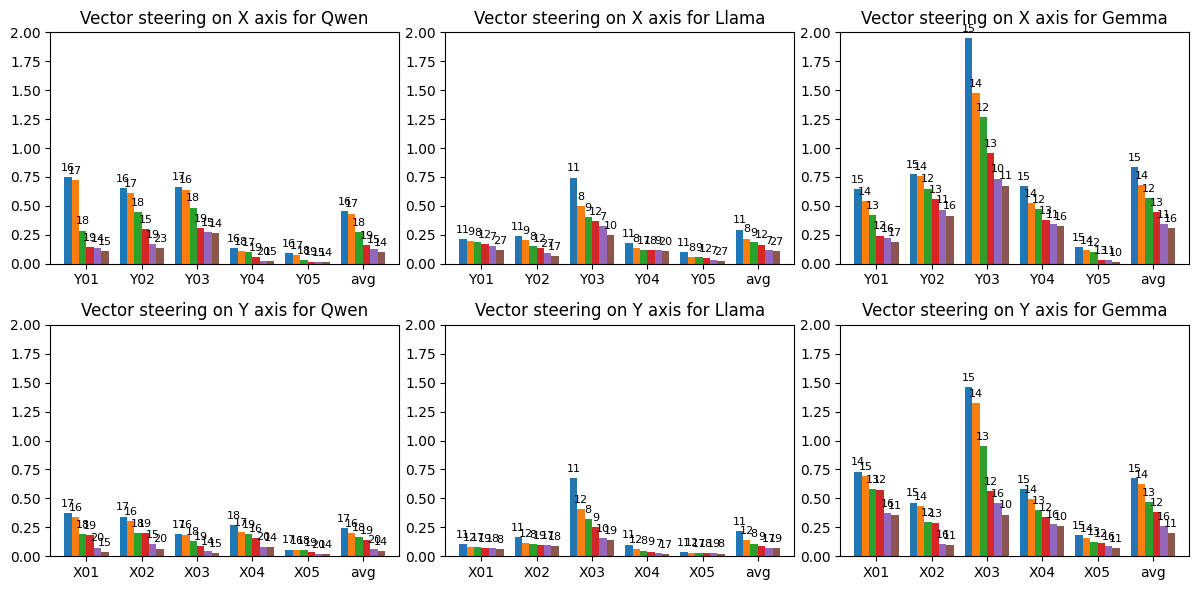

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Prepare data: Extract both values AND the corresponding indices
X_diff = best_layers_X.abs().apply(lambda x: x.nlargest(25).values.tolist(), axis=0)
X_inds = best_layers_X.abs().apply(lambda x: x.nlargest(25).index.tolist(), axis=0)

Y_diff = best_layers_Y.abs().apply(lambda x: x.nlargest(25).values.tolist(), axis=0)
Y_inds = best_layers_Y.abs().apply(lambda x: x.nlargest(25).index.tolist(), axis=0)

X_diff_llama = best_layers_X_llama.abs().apply(lambda x: x.nlargest(25).values.tolist(), axis=0)
X_inds_llama = best_layers_X_llama.abs().apply(lambda x: x.nlargest(25).index.tolist(), axis=0)

Y_diff_llama = best_layers_Y_llama.abs().apply(lambda x: x.nlargest(25).values.tolist(), axis=0)
Y_inds_llama = best_layers_Y_llama.abs().apply(lambda x: x.nlargest(25).index.tolist(), axis=0)

X_diff_gemma = best_layers_X_gemma.abs().apply(lambda x: x.nlargest(25).values.tolist(), axis=0)
X_inds_gemma = best_layers_X_gemma.abs().apply(lambda x: x.nlargest(25).index.tolist(), axis=0)
Y_diff_gemma = best_layers_Y_gemma.abs().apply(lambda x: x.nlargest(25).values.tolist(), axis=0)
Y_inds_gemma = best_layers_Y_gemma.abs().apply(lambda x: x.nlargest(25).index.tolist(), axis=0)

# 2. Plotting
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

# Helper function to plot and annotate
def plot_with_labels(df_vals, df_inds, ax, title):
    # Plot the first 4 ranks
    # df_vals.iloc[0:4, :].T.sort_index().plot(kind='bar', ax=ax, title=title, legend=False, rot=0, width=0.8)
    df_vals.iloc[0:6, :].T.sort_index().plot(kind='bar', ax=ax, title=title, legend=False, rot=0, ylim=(0,2), width=0.8)
    
    # Iterate through the containers (each container represents one rank: 1st, 2nd, 3rd, 4th)
    for i, container in enumerate(ax.containers):
        # The labels for the i-th rank across all columns
        labels = df_inds.iloc[i, :]
        # Add labels on top of bars (rotation=90 makes them readable)
        ax.bar_label(container, labels=labels, padding=3, rotation=0, fontsize=8)

plot_with_labels(X_diff, X_inds, axs[0, 0], 'Vector steering on X axis for Qwen')
plot_with_labels(X_diff_llama, X_inds_llama, axs[0, 1], 'Vector steering on X axis for Llama')
plot_with_labels(X_diff_gemma, X_inds_gemma, axs[0, 2], 'Vector steering on X axis for Gemma')
plot_with_labels(Y_diff, Y_inds, axs[1, 0], 'Vector steering on Y axis for Qwen')
plot_with_labels(Y_diff_llama, Y_inds_llama, axs[1, 1], 'Vector steering on Y axis for Llama')
plot_with_labels(Y_diff_gemma, Y_inds_gemma, axs[1, 2], 'Vector steering on Y axis for Gemma')

# plt.suptitle('Top 4 Layers with Highest Steering Differential per Question', fontsize=16)
plt.tight_layout()
plt.show()


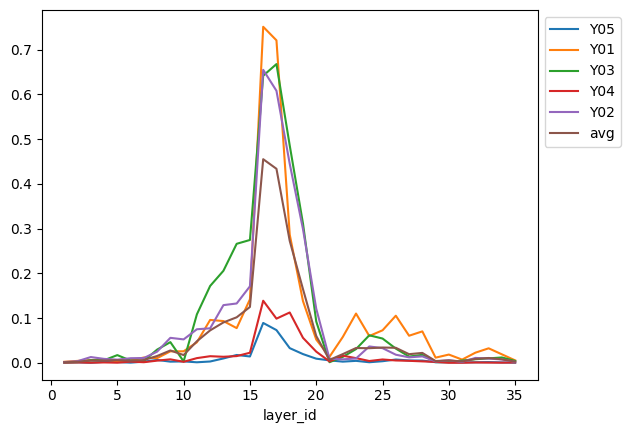

In [35]:
best_layers_X[::-1].abs().plot(kind='line', legend=False, rot=0)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

('Y01', 'Y02', 'Y03', 'Y04', 'Y05', 'avg')
('Y01', 'Y02', 'Y03', 'Y04', 'Y05', 'avg')


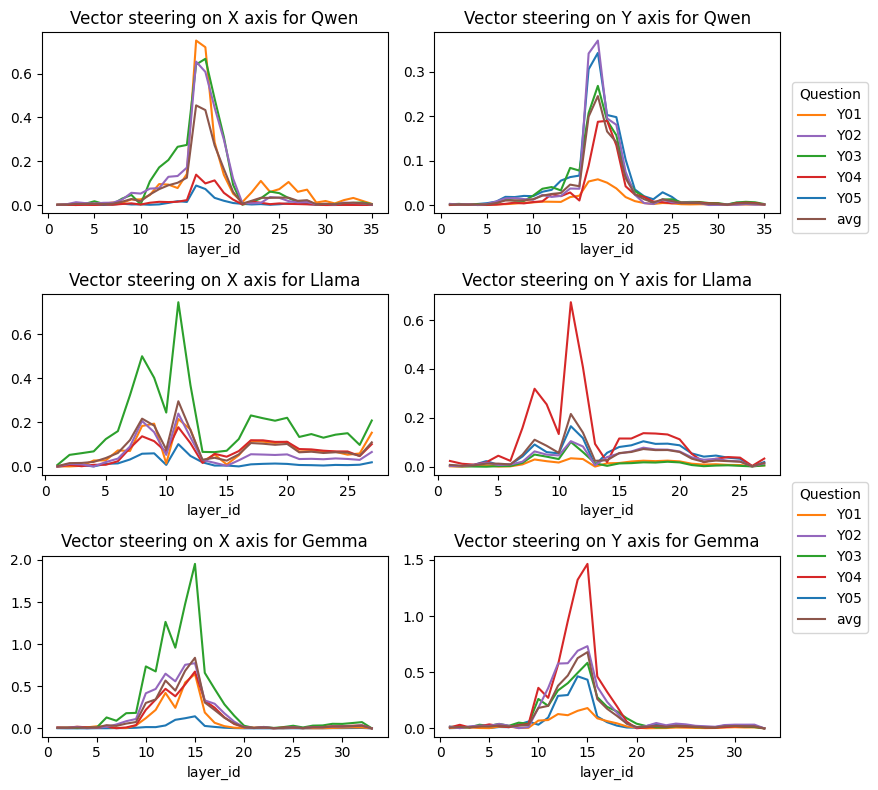

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

# 2. Plotting
fig, axs = plt.subplots(3, 2, figsize=(8, 8))

# Helper function to plot and annotate
def plot_with_labels(df_vals, ax, title):
	# df_vals[::-1].plot(kind='line', legend=False, rot=0, ax=ax, title=title)
	df_vals[::-1].abs().plot(kind='line', legend=False, rot=0, ax=ax, title=title)

plot_with_labels(best_layers_X, axs[0, 0], 'Vector steering on X axis for Qwen')
plot_with_labels(best_layers_X_llama, axs[1, 0], 'Vector steering on X axis for Llama')
plot_with_labels(best_layers_X_gemma, axs[2, 0], 'Vector steering on X axis for Gemma')
plot_with_labels(best_layers_Y, axs[0, 1], 'Vector steering on Y axis for Qwen')
plot_with_labels(best_layers_Y_llama, axs[1, 1], 'Vector steering on Y axis for Llama')
plot_with_labels(best_layers_Y_gemma, axs[2, 1], 'Vector steering on Y axis for Gemma')


handles, labels = [], []
# for ax in axs.flat:
h, l = axs[1,0].get_legend_handles_labels()
for hh, ll in zip(h, l):
	if ll and ll != "_nolegend_" and ll not in labels:
		handles.append(hh)
		labels.append(ll)
#sort labels and handles by labels
labels, handles = zip(*sorted(zip(labels, handles)))
print(labels)
fig.legend(
	handles,
	labels,
	# loc="lower left",
	bbox_to_anchor=(1.1, 0.9),
	ncol=min(1, max(1, len(labels))),
	# frameon=False,
	title="Question"
)
handles, labels = [], []
# for ax in axs.flat:
h, l = axs[0,0].get_legend_handles_labels()
for hh, ll in zip(h, l):
	if ll and ll != "_nolegend_" and ll not in labels:
		handles.append(hh)
		labels.append(ll)
#sort labels and handles by labels
labels, handles = zip(*sorted(zip(labels, handles)))
print(labels)
fig.legend(
	handles,
	labels,
	# loc="lower right",
	bbox_to_anchor=(1.1, 0.4),
	ncol=min(1, max(1, len(labels))),
	# frameon=False,
	title="Question"
)
fig.subplots_adjust(top=0.90)
plt.tight_layout()
plt.show()


In [37]:
tmp =pd.concat([X_diff['avg'], X_diff_llama['avg'], X_diff_gemma['avg'], Y_diff['avg'], Y_diff_llama['avg'], Y_diff_gemma['avg']],axis=1, keys=['X_diff_Qwen', 'X_diff_Llama', 'X_diff_Gemma', 'Y_diff_Qwen', 'Y_diff_Llama', 'Y_diff_Gemma'])
# print(tmp.to_csv())
tmp

,X_diff_Qwen,X_diff_Llama,X_diff_Gemma,Y_diff_Qwen,Y_diff_Llama,Y_diff_Gemma
0,0.454942,0.296164,0.837953,0.245355,0.215762,0.678415
1,0.433519,0.217438,0.683490,0.199158,0.139591,0.625137
2,0.272429,0.185857,0.567512,0.165641,0.110349,0.470321
3,0.164599,0.165284,0.448536,0.141500,0.085529,0.379011
4,0.124751,0.120516,0.343849,0.060532,0.072313,0.260862
5,0.101665,0.110289,0.307292,0.045975,0.068185,0.200070
6,0.090154,0.107136,0.301879,0.042342,0.067884,0.181428
7,0.072423,0.103987,0.218110,0.027084,0.060243,0.174202
8,0.059821,0.102924,0.125489,0.024937,0.060195,0.111189
9,0.048117,0.099050,0.075198,0.024344,0.056524,0.042940


('X01', 'X02', 'X03', 'X04', 'X05', 'avg')
('Y01', 'Y02', 'Y03', 'Y04', 'Y05', 'avg')


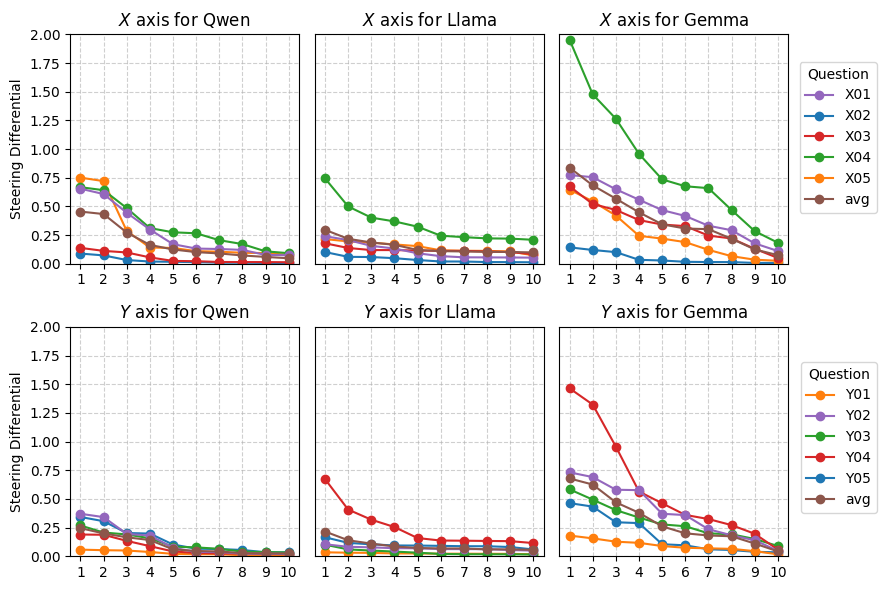

In [38]:

fig, axs = plt.subplots(2, 3, figsize=(8, 6))

def plot_line_with_labels(df_vals, df_inds, ax, title, yticks=False):
	# Prepare the data: rows=questions, columns=ranks (1st to 4th)
	plot_data = df_vals.iloc[0:10, :].sort_index()
	label_data = df_inds.iloc[0:10, :].sort_index()
	
	# Plot lines with markers
	plot_data.plot(kind='line', ax=ax, marker='o', title=title, legend=False, rot=0)
	
	# Formatting
	ax.set_ylim(0, 2)
	# remove y ticks
	ax.grid(True, linestyle='--', alpha=0.6)
	if not yticks:
		# ax.set_yticks([])
		ax.set_ylabel('')
		ax.tick_params(axis='y', left=False, labelleft=False)
	else:
		ax.set_ylabel('Steering Differential')
	ax.set_xticks(range(len(plot_data.index)))
	ax.set_xticklabels(range(1, len(plot_data.index) + 1))

# Execute plotting
plot_line_with_labels(X_diff, X_inds, axs[0, 0], '$X$ axis for Qwen', yticks=True)
plot_line_with_labels(X_diff_llama, X_inds_llama, axs[0, 1], '$X$ axis for Llama')
plot_line_with_labels(X_diff_gemma, X_inds_gemma, axs[0, 2], '$X$ axis for Gemma')
plot_line_with_labels(Y_diff, Y_inds, axs[1, 0], '$Y$ axis for Qwen', yticks=True)
plot_line_with_labels(Y_diff_llama, Y_inds_llama, axs[1, 1], '$Y$ axis for Llama')
plot_line_with_labels(Y_diff_gemma, Y_inds_gemma, axs[1, 2], '$Y$ axis for Gemma')
# plt.suptitle('Top 4 Layers with Highest Steering Differential per Question', fontsize=16)
# Add one shared legend for all subplots
handles, labels = [], []
# for ax in axs.flat:
h, l = axs[1,0].get_legend_handles_labels()
for hh, ll in zip(h, l):
	if ll and ll != "_nolegend_" and ll not in labels:
		handles.append(hh)
		labels.append(ll)
#sort labels and handles by labels
labels, handles = zip(*sorted(zip(labels, handles)))
print(labels)
fig.legend(
	handles,
	labels,
	# loc="lower left",
	bbox_to_anchor=(1.1, 0.9),
	ncol=min(1, max(1, len(labels))),
	# frameon=False,
	title="Question"
)
handles, labels = [], []
# for ax in axs.flat:
h, l = axs[0,0].get_legend_handles_labels()
for hh, ll in zip(h, l):
	if ll and ll != "_nolegend_" and ll not in labels:
		handles.append(hh)
		labels.append(ll)
#sort labels and handles by labels
labels, handles = zip(*sorted(zip(labels, handles)))
print(labels)
fig.legend(
	handles,
	labels,
	# loc="lower right",
	bbox_to_anchor=(1.1, 0.4),
	ncol=min(1, max(1, len(labels))),
	# frameon=False,
	title="Question"
)
fig.subplots_adjust(top=0.90)
plt.tight_layout()
plt.show()


In [39]:
# save X_diff, y_diff of all models to json
diff_json = {
	'X axis for Qwen': X_diff[:10].to_dict(),
	'X axis for Llama': X_diff_llama[:10].to_dict(),
	'X axis for Gemma': X_diff_gemma[:10].to_dict(),
	'Y axis for Qwen': Y_diff[:10].to_dict(),
	'Y axis for Llama': Y_diff_llama[:10].to_dict(),
	'Y axis for Gemma': Y_diff_gemma[:10].to_dict(),
}
#save to json file
import json
# with open('../outputs/steering_differential_top10.json', 'w') as f:
# 	json.dump(diff_json, f, indent=4)
print(json.dumps(diff_json, indent=4))
# print(diff_df.to_csv(index=True))

{
    "X axis for Qwen": {
        "Y05": {
            "0": 0.0890147930966724,
            "1": 0.0730509531664815,
            "2": 0.0327667839204268,
            "3": 0.0194518024722731,
            "4": 0.0174313199706372,
            "5": 0.0141381885856386,
            "6": 0.0096778279170393,
            "7": 0.0091849450021981,
            "8": 0.007288371274869,
            "9": 0.0063495787481464
        },
        "Y01": {
            "0": 0.7508534222049104,
            "1": 0.7205678848804382,
            "2": 0.2864982299963241,
            "3": 0.1418182750301646,
            "4": 0.1378234805240943,
            "5": 0.1100381209425904,
            "6": 0.1052163001168544,
            "7": 0.0957609743091776,
            "8": 0.0932458636908446,
            "9": 0.0774966253641658
        },
        "Y03": {
            "0": 0.6675031644495899,
            "1": 0.641546656273567,
            "2": 0.4856760084978297,
            "3": 0.3111992420163005,
            "4":

In [40]:
best_layers_Y.abs().apply(lambda x: x.nlargest(10).index.tolist(), axis=0)


,X02,X05,X04,X03,X01,avg
0,17,17,17,18,17,17
1,16,16,16,17,16,16
2,18,18,18,19,18,18
3,19,19,19,16,19,19
4,20,15,14,20,20,20
5,15,20,15,14,14,14
6,14,14,20,12,15,15
7,13,21,12,21,21,13
8,21,11,11,13,11,12
9,12,12,13,22,13,21


In [41]:
best_layers_X.abs().apply(lambda x: x.nlargest(10).index.tolist(), axis=0)


,Y05,Y01,Y03,Y04,Y02,avg
0,16,16,17,16,16,16
1,17,17,16,18,17,17
2,18,18,18,17,18,18
3,19,15,19,19,19,19
4,14,19,15,20,15,15
5,15,23,14,15,14,14
6,13,26,13,22,13,13
7,20,12,12,14,20,12
8,26,13,11,12,12,20
9,8,14,20,13,11,11


In [42]:
best_layers_Y_llama.abs().apply(lambda x: x.nlargest(10).index.tolist(), axis=0)


,X02,X05,X04,X03,X01,avg
0,11,11,11,11,11,11
1,12,12,12,12,12,12
2,17,8,8,8,17,8
3,19,19,9,9,18,9
4,18,17,10,7,19,17
5,8,18,19,17,8,19
6,20,9,17,18,16,18
7,16,20,20,10,20,20
8,15,16,18,19,15,16
9,9,10,7,15,9,10


# Perplexity analysis

In [55]:
#plot perplexity change
import json
import numpy as np
import matplotlib.pyplot as plt
with open('../X_perplexity.json', 'r') as f:
	X_perplexity = json.load(f)
X_perplexity_2 = X_perplexity
X_perplexity = [x[0] for x in X_perplexity]

with open('../Y_perplexity.json', 'r') as f:
	Y_perplexity = json.load(f)
Y_perplexity = [x[0] for x in Y_perplexity]

with open('../X_perplexity_llama.json', 'r') as f:
	X_perplexity_llama = json.load(f)
X_perplexity_llama = [x[0] for x in X_perplexity_llama]

with open('../Y_perplexity_llama.json', 'r') as f:
	Y_perplexity_llama = json.load(f)
Y_perplexity_llama = [x[0] for x in Y_perplexity_llama]
with open('../X_perplexity_gemma.json', 'r') as f:
	X_perplexity_gemma = json.load(f)
X_perplexity_gemma = [x[0] for x in X_perplexity_gemma]
with open('../Y_perplexity_gemma.json', 'r') as f:
	Y_perplexity_gemma = json.load(f)
Y_perplexity_gemma = [x[0] for x in Y_perplexity_gemma]



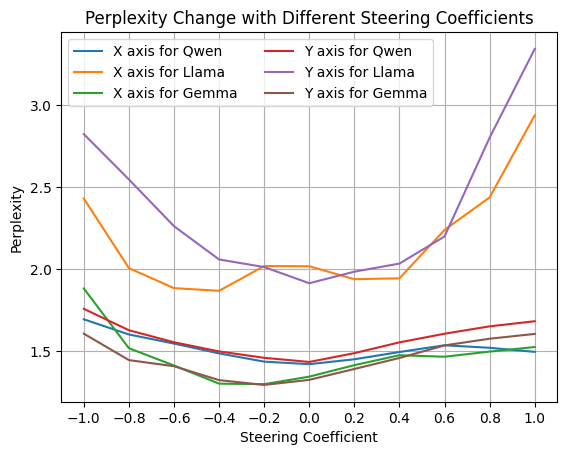

In [44]:
cofs = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8,1]
plt.plot(cofs, X_perplexity, label='X axis for Qwen')
plt.plot(cofs, X_perplexity_llama, label='X axis for Llama')
plt.plot(cofs, X_perplexity_gemma, label='X axis for Gemma')
plt.plot(cofs, Y_perplexity, label='Y axis for Qwen')
plt.plot(cofs, Y_perplexity_llama, label='Y axis for Llama')
plt.plot(cofs, Y_perplexity_gemma, label='Y axis for Gemma')
plt.xticks(cofs)
# plt.ylim(1.2, 2)
plt.xlabel('Steering Coefficient')
plt.ylabel('Perplexity')
plt.title('Perplexity Change with Different Steering Coefficients')
plt.legend(ncol=2, loc='upper left')
plt.grid()
plt.show()

In [45]:
# export csv for perplexity change
perplexity_df = pd.DataFrame({
	'Steering Coefficient': cofs,
	'X axis for Qwen': X_perplexity,
	'X axis for Llama': X_perplexity_llama,
	'X axis for Gemma': X_perplexity_gemma,
	'Y axis for Qwen': Y_perplexity,
	'Y axis for Llama': Y_perplexity_llama,
	'Y axis for Gemma': Y_perplexity_gemma,
})
print(perplexity_df.to_csv(index=False))

Steering Coefficient,X axis for Qwen,X axis for Llama,X axis for Gemma,Y axis for Qwen,Y axis for Llama,Y axis for Gemma
-1.0,1.694186770915985,2.4304231643676757,1.8821245431900024,1.757962014277776,2.82329261302948,1.6066561182339987
-0.8,1.601870334148407,2.006419571240743,1.518044223388036,1.627683796485265,2.546921642621358,1.4454701205094656
-0.6,1.5464154223601023,1.8843623340129851,1.412615523735682,1.5542870839436849,2.2619501252969108,1.4082033415635427
-0.4,1.4863702992598216,1.8680040518442789,1.3018262247244516,1.4984983483950296,2.059111112356186,1.3234615008036295
-0.2,1.436171176036199,2.0190708061059315,1.2989071349302928,1.45941570798556,2.012826414903005,1.2942141671975453
0.0,1.420733638604482,2.0177034278710684,1.3447380701700846,1.4342578570048015,1.9141895115375518,1.3250787814458211
0.2,1.4505694925785064,1.9387957195440928,1.4147664169470469,1.4878829816977184,1.9846628924210867,1.391449217001597
0.4,1.4948207934697468,1.9441647132237752,1.475266162554423,1.553

## MMLU Performance

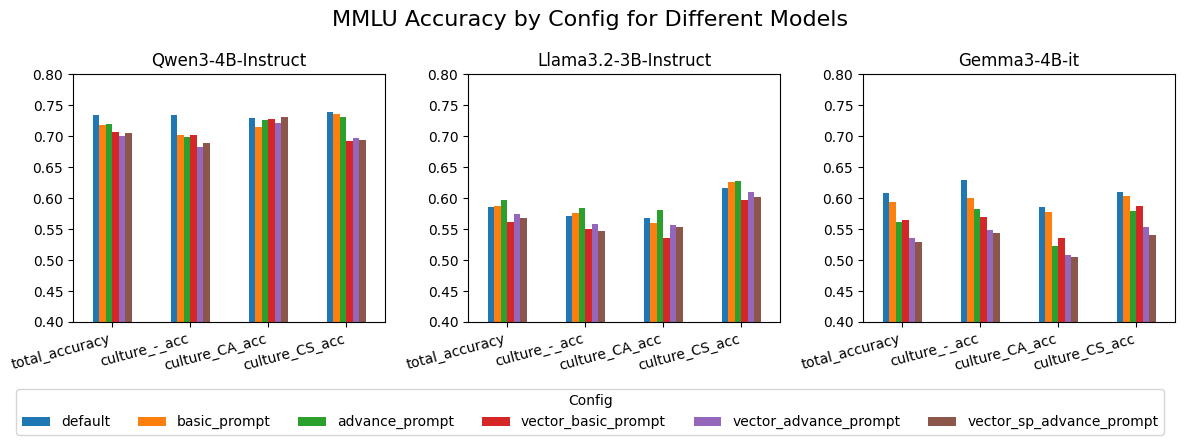

In [46]:
import pandas as pd
from matplotlib import pyplot as plt
#load MMLU results
llama_mmlu = pd.read_csv('../outputs/global_mmlu/meta-llama_Llama-3.2-3B-Instruct/global_mmlu_summary.csv')
qwen_mmlu = pd.read_csv('../outputs/global_mmlu/qwen_Qwen3-4B-Instruct-2507/global_mmlu_summary.csv')
gemma_mmlu = pd.read_csv('../outputs/global_mmlu/google_gemma-3-4b-it/global_mmlu_summary.csv')
# qwen_mmlu
# plot acc change by config keep the order of config
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

qwen_mmlu.groupby('config', sort=False)[['total_accuracy', 'culture_-_acc', 'culture_CA_acc', 'culture_CS_acc']]\
    .mean().T.plot(ax=ax[0], kind='bar', title="Qwen3-4B-Instruct", legend=False)
    
llama_mmlu.groupby('config', sort=False)[['total_accuracy', 'culture_-_acc', 'culture_CA_acc', 'culture_CS_acc']]\
    .mean().T.plot(ax=ax[1], kind='bar', title="Llama3.2-3B-Instruct", legend=True)

gemma_mmlu.groupby('config', sort=False)[['total_accuracy', 'culture_-_acc', 'culture_CA_acc', 'culture_CS_acc']]\
	.mean().T.plot(ax=ax[2], kind='bar', title="Gemma3-4B-it", legend=False)
# Set y-axis limits for both subplots
for axis in ax:
    axis.set_ylim(0.4, 0.8)

# Move shared legend to bottom
handles, labels = ax[1].get_legend_handles_labels()
ax[1].get_legend().remove()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=6, title='Config')

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=15, ha='right')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=15, ha='right')
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=15, ha='right')

plt.suptitle('MMLU Accuracy by Config for Different Models', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)

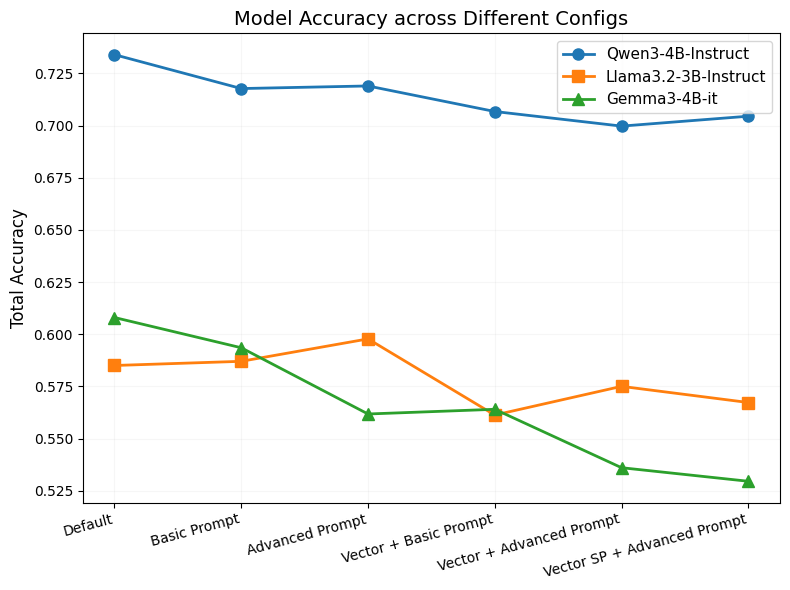

In [47]:
# Plot line diagram: Config vs Total Accuracy by Model
fig, ax = plt.subplots(figsize=(8, 6))

# Map raw config keys to display labels in the figure
config_display_map = {
    'default': 'Default',
    'basic_prompt': 'Basic Prompt',
    'advance_prompt': 'Advanced Prompt',
    'vector_basic_prompt': 'Vector + Basic Prompt',
    'vector_advance_prompt': 'Vector + Advanced Prompt',
    'vector_sp_advance_prompt': 'Vector SP + Advanced Prompt'
}

# Group by config and get mean total_accuracy for each model
qwen_accuracy = qwen_mmlu.groupby('config', sort=False)['total_accuracy'].mean()
llama_accuracy = llama_mmlu.groupby('config', sort=False)['total_accuracy'].mean()
gemma_accuracy = gemma_mmlu.groupby('config', sort=False)['total_accuracy'].mean()
# Apply mapped labels for plotting
x_labels = [config_display_map.get(cfg, cfg) for cfg in qwen_accuracy.index]

# Plot lines for each model
ax.plot(x_labels, qwen_accuracy.values, marker='o', linewidth=2, markersize=8, label='Qwen3-4B-Instruct')
ax.plot(x_labels, llama_accuracy.values, marker='s', linewidth=2, markersize=8, label='Llama3.2-3B-Instruct')
ax.plot(x_labels, gemma_accuracy.values, marker='^', linewidth=2, markersize=8, label='Gemma3-4B-it')
# Formatting
# ax.set_xlabel('Config', fontsize=12)s
ax.set_ylabel('Total Accuracy', fontsize=12)
ax.set_title('Model Accuracy across Different Configs', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

In [48]:
print(llama_mmlu.groupby('config', sort=False)[['total_accuracy', 'culture_-_acc', 'culture_CA_acc', 'culture_CS_acc']]\
    .mean().T.to_csv())

,default,basic_prompt,advance_prompt,vector_basic_prompt,vector_advance_prompt,vector_sp_advance_prompt
total_accuracy,0.585,0.587,0.59775,0.56125,0.575,0.56725
culture_-_acc,0.5718562874251497,0.5755988023952096,0.5845808383233533,0.5508982035928144,0.5576347305389222,0.5464071856287425
culture_CA_acc,0.5675675675675675,0.56006006006006,0.5810810810810811,0.5360360360360361,0.557057057057057,0.5533033033033034
culture_CS_acc,0.6156156156156156,0.6253753753753754,0.6276276276276276,0.5968468468468469,0.6103603603603603,0.6021021021021021

